In [2]:
#Importing basic libraries
import pandas as pd
import numpy as np

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.ensemble import IsolationForest

import xgboost as xgb

In [4]:
# ---- PyTorch Autoencoder ----
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [5]:
data = pd.read_csv("DNN-EdgeIIoT-dataset (1).csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_856\1583937634.py:1: DtypeWarning: Columns (2,3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("DNN-EdgeIIoT-dataset (1).csv")


In [6]:
y_label = data["Attack_label"].astype(int).values
y_type_raw = data["Attack_type"].astype(str).values
X = data.drop(columns=["Attack_label", "Attack_type"]).copy()


In [7]:
mixed_cols = [2,3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55]
for col in mixed_cols:
    X.iloc[:, col] = X.iloc[:, col].astype(str)

# Identify categorical & numeric columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

In [8]:
# Splitting

X_train, X_temp, y_train_label, y_temp_label, y_train_type_raw, y_temp_type_raw = train_test_split(
    X, y_label, y_type_raw, test_size=0.2, random_state=42, stratify=y_label
)
X_val, X_test, y_val_label, y_test_label, y_val_type_raw, y_test_type_raw = train_test_split(
    X_temp, y_temp_label, y_temp_type_raw, test_size=0.5, random_state=42, stratify=y_temp_label
)


In [9]:
# Label-encode categorical features 

cat_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    # For val/test, handle unseen categories safely:
    mapping = {cls: i for i, cls in enumerate(le.classes_)}
    unknown_id = len(le.classes_)

    def transform_safe(series):
        return series.astype(str).map(mapping).fillna(unknown_id).astype(int)

    X_val[col] = transform_safe(X_val[col])
    X_test[col] = transform_safe(X_test[col])

    cat_encoders[col] = (le, unknown_id)

# Ensure numeric columns are numeric
for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce").fillna(0)
    X_val[col]   = pd.to_numeric(X_val[col], errors="coerce").fillna(0)
    X_test[col]  = pd.to_numeric(X_test[col], errors="coerce").fillna(0)


In [10]:
#Scale ONLY numeric columns 

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols]).astype(np.float32)
X_val_num   = scaler.transform(X_val[num_cols]).astype(np.float32)
X_test_num  = scaler.transform(X_test[num_cols]).astype(np.float32)

# Categorical part as float32 
X_train_cat = X_train[cat_cols].values.astype(np.float32) if cat_cols else np.empty((len(X_train), 0), np.float32)
X_val_cat   = X_val[cat_cols].values.astype(np.float32) if cat_cols else np.empty((len(X_val), 0), np.float32)
X_test_cat  = X_test[cat_cols].values.astype(np.float32) if cat_cols else np.empty((len(X_test), 0), np.float32)

# Final features
X_train_all = np.concatenate([X_train_num, X_train_cat], axis=1)
X_val_all   = np.concatenate([X_val_num,   X_val_cat],   axis=1)
X_test_all  = np.concatenate([X_test_num,  X_test_cat],  axis=1)

print("Feature shapes:", X_train_all.shape, X_val_all.shape, X_test_all.shape)


Feature shapes: (1775360, 61) (221920, 61) (221921, 61)


In [11]:
# Autoencoder trained on NORMAL only

X_train_normal = X_train_all[y_train_label == 0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_normal.shape[1]

latent_dim = 64
hidden1, hidden2 = 256, 128
epochs = 10
batch_size = 1024
lr = 1e-3

class Autoencoder(nn.Module):
    def __init__(self, in_dim, latent_dim=32, h1=256, h2=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, h1), nn.ReLU(),
            nn.Linear(h1, h2), nn.ReLU(),
            nn.Linear(h2, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, h2), nn.ReLU(),
            nn.Linear(h2, h1), nn.ReLU(),
            nn.Linear(h1, in_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)
    def encode(self, x):
        return self.encoder(x)

ae = Autoencoder(input_dim, latent_dim, hidden1, hidden2).to(device)
opt = torch.optim.Adam(ae.parameters(), lr=lr)
loss_fn = nn.MSELoss()

loader = DataLoader(TensorDataset(torch.from_numpy(X_train_normal)), batch_size=batch_size, shuffle=True)

ae.train()
for e in range(1, epochs + 1):
    losses = []
    for (xb,) in loader:
        xb = xb.to(device)
        opt.zero_grad()
        x_hat = ae(xb)
        loss = loss_fn(x_hat, xb)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    print(f"AE Epoch {e:02d}/{epochs} | MSE: {np.mean(losses):.6f}")

@torch.no_grad()
def ae_features(X_np):
    ae.eval()
    X_t = torch.from_numpy(X_np).to(device)
    Z = ae.encode(X_t).cpu().numpy()
    X_hat = ae(X_t).cpu().numpy()
    recon = np.mean((X_np - X_hat) ** 2, axis=1, keepdims=True)
    F = np.concatenate([Z, recon], axis=1)
    return F

F_train_normal = ae_features(X_train_normal)
F_val  = ae_features(X_val_all)
F_test = ae_features(X_test_all)

AE Epoch 01/10 | MSE: 139185578.760417
AE Epoch 02/10 | MSE: 359746.056416
AE Epoch 03/10 | MSE: 458318.795261
AE Epoch 04/10 | MSE: 713111.831517
AE Epoch 05/10 | MSE: 733593.552023
AE Epoch 06/10 | MSE: 664890.319811
AE Epoch 07/10 | MSE: 595790.276416
AE Epoch 08/10 | MSE: 499652.732598
AE Epoch 09/10 | MSE: 532397.435787
AE Epoch 10/10 | MSE: 679020.465594


In [12]:
# Isolation Forest for Attack_label

iso = IsolationForest(n_estimators=300, contamination="auto", random_state=42, n_jobs=-1)
iso.fit(F_train_normal)

val_score  = -iso.decision_function(F_val)
test_score = -iso.decision_function(F_test)

threshold = np.percentile(val_score[y_val_label == 0], 80)
y_val_pred_label  = (val_score > threshold).astype(int)
y_test_pred_label = (test_score > threshold).astype(int)

print("Stage 1: Attack_label (VAL)")
print(confusion_matrix(y_val_label, y_val_pred_label))
print(classification_report(y_val_label, y_val_pred_label, digits=4))
print("ROC-AUC:", roc_auc_score(y_val_label, val_score))

print("\n=== Stage 1: Attack_label (TEST) ===")
print(confusion_matrix(y_test_label, y_test_pred_label))
print(classification_report(y_test_label, y_test_pred_label, digits=4))
print("ROC-AUC:", roc_auc_score(y_test_label, test_score))

Stage 1: Attack_label (VAL)
[[133974  27590]
 [ 44917  15439]]
              precision    recall  f1-score   support

           0     0.7489    0.8292    0.7870    161564
           1     0.3588    0.2558    0.2987     60356

    accuracy                         0.6733    221920
   macro avg     0.5539    0.5425    0.5428    221920
weighted avg     0.6428    0.6733    0.6542    221920

ROC-AUC: 0.6688388705253225

=== Stage 1: Attack_label (TEST) ===
[[133919  27646]
 [ 44951  15405]]
              precision    recall  f1-score   support

           0     0.7487    0.8289    0.7868    161565
           1     0.3578    0.2552    0.2979     60356

    accuracy                         0.6729    221921
   macro avg     0.5533    0.5421    0.5424    221921
weighted avg     0.6424    0.6729    0.6538    221921

ROC-AUC: 0.6693718731634529


In [13]:
# XGBoost for Attack_type on predicted attacks

train_attack_mask = (y_train_label == 1)

X_train_att = X_train_all[train_attack_mask]
y_train_type_att_raw = y_train_type_raw[train_attack_mask]

val_attack_mask  = (y_val_pred_label == 1)
test_attack_mask = (y_test_pred_label == 1)

if val_attack_mask.sum() == 0 or test_attack_mask.sum() == 0:
    print("\nStage 2 skipped: no attacks predicted by stage 1. Lower threshold (e.g., 90th percentile).")
else:
    le_type = LabelEncoder()
    y_train_type_att = le_type.fit_transform(y_train_type_att_raw)

    y_val_type_att_raw  = y_val_type_raw[val_attack_mask]
    y_test_type_att_raw = y_test_type_raw[test_attack_mask]

    # Filter unknown labels (rare)
    known = set(le_type.classes_)
    val_keep  = np.array([t in known for t in y_val_type_att_raw])
    test_keep = np.array([t in known for t in y_test_type_att_raw])

    X_val_att  = X_val_all[val_attack_mask][val_keep]
    X_test_att = X_test_all[test_attack_mask][test_keep]

    y_val_type_att  = le_type.transform(y_val_type_att_raw[val_keep])
    y_test_type_att = le_type.transform(y_test_type_att_raw[test_keep])

    # Use AE features as XGBoost input
    F_train_att = ae_features(X_train_att)
    F_val_att   = ae_features(X_val_att)
    F_test_att  = ae_features(X_test_att)

    clf = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=len(le_type.classes_),
        n_estimators=1500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
)

    clf.fit(F_train_att, y_train_type_att,eval_set=[(F_val_att, y_val_type_att)],verbose=100,
            )

    val_pred = clf.predict(F_val_att)
    test_pred = clf.predict(F_test_att)

    

[0]	validation_0-mlogloss:2.68582
[100]	validation_0-mlogloss:3.61204
[200]	validation_0-mlogloss:5.56985
[300]	validation_0-mlogloss:6.37373
[400]	validation_0-mlogloss:6.83708
[500]	validation_0-mlogloss:7.02935
[600]	validation_0-mlogloss:7.27998
[700]	validation_0-mlogloss:7.38752
[800]	validation_0-mlogloss:7.47368
[900]	validation_0-mlogloss:7.61036
[1000]	validation_0-mlogloss:7.67732
[1100]	validation_0-mlogloss:7.78640
[1200]	validation_0-mlogloss:7.88082
[1300]	validation_0-mlogloss:7.88908
[1400]	validation_0-mlogloss:7.95294
[1499]	validation_0-mlogloss:7.99195


In [14]:
labels_all = np.arange(len(le_type.classes_)) 

print("Stage 2: Attack_type (VAL, predicted attacks only) ")
print("Accuracy:", accuracy_score(y_val_type_att, val_pred))
print(confusion_matrix(y_val_type_att, val_pred))
print(classification_report(y_val_type_att,val_pred,labels=labels_all,target_names=le_type.classes_,digits=4,zero_division=0))
   

Stage 2: Attack_type (VAL, predicted attacks only) 
Accuracy: 0.06107908543299437
[[  16    0   53    2    0 2185    0    0    0    0]
 [   0    0 1013   78    0  830    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0   29    0   10    0    0    0    0]
 [   0    0    0  167    0 1846    0    0   26    0]
 [   0    0    0    3    0  861    0    0    0    0]
 [   0    0    0    3    0 2842    0    0    0    0]
 [   0    0    0  201    0  641    0    1    7    0]
 [   0    0    0  281    0 3988    0    0   36    0]
 [   0    0    0   57    0  252    0    0   11    0]]
                       precision    recall  f1-score   support

             Backdoor     1.0000    0.0071    0.0141      2256
            DDoS_HTTP     0.0000    0.0000    0.0000      1921
            DDoS_ICMP     0.0000    0.0000    0.0000         0
             DDoS_TCP     0.0000    0.0000    0.0000         0
             DDoS_UDP     0.0000    0.0000    0.0000         0
       F

In [25]:
print("Stage 2: Attack_type (TEST, predicted attacks only) ")
print("Accuracy:", accuracy_score(y_test_type_att, test_pred))

print(classification_report(y_test_type_att,test_pred,labels=np.arange(len(le_type.classes_)),target_names=le_type.classes_,digits=4,zero_division=0))

Stage 2: Attack_type (TEST, predicted attacks only) 
Accuracy: 0.06335605322947095
                       precision    recall  f1-score   support

             Backdoor     1.0000    0.0058    0.0114      2258
            DDoS_HTTP     0.0000    0.0000    0.0000      1888
            DDoS_ICMP     0.0000    0.0000    0.0000         0
             DDoS_TCP     0.0000    0.0000    0.0000         0
             DDoS_UDP     0.0000    0.0000    0.0000         0
       Fingerprinting     0.0000    0.0000    0.0000         0
                 MITM     0.0342    0.8235    0.0657        34
             Password     0.0000    0.0000    0.0000      2020
        Port_Scanning     0.0000    0.0000    0.0000         0
           Ransomware     0.0666    0.9978    0.1249       896
        SQL_injection     0.0000    0.0000    0.0000      2877
            Uploading     0.0000    0.0000    0.0000       834
Vulnerability_scanner     0.4184    0.0096    0.0188      4261
                  XSS     0.0000  

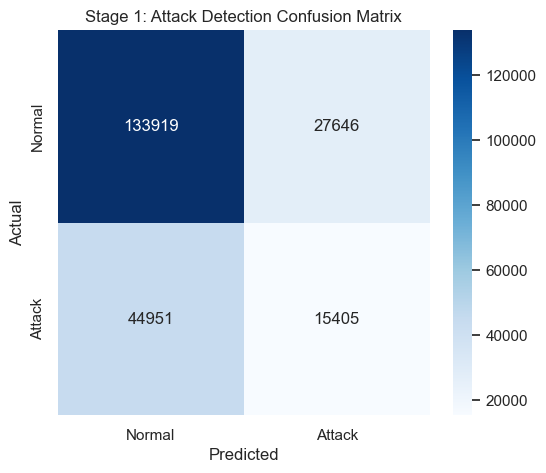

In [26]:

plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test_label, y_test_pred_label)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Normal","Attack"],
            yticklabels=["Normal","Attack"])

plt.title("Stage 1: Attack Detection Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

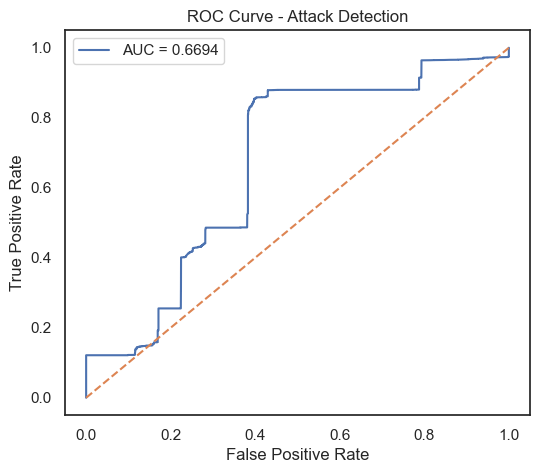

In [27]:
fpr, tpr, thresholds = roc_curve(y_test_label, test_score)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_label, test_score):.4f}")
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve - Attack Detection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

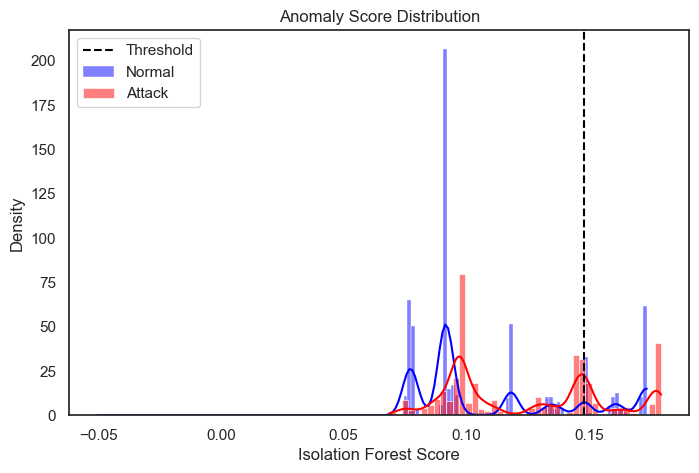

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(test_score[y_test_label==0],
             color="blue",
             label="Normal",
             kde=True,
             stat="density")

sns.histplot(test_score[y_test_label==1],
             color="red",
             label="Attack",
             kde=True,
             stat="density")

plt.axvline(threshold, color="black", linestyle="--", label="Threshold")

plt.title("Anomaly Score Distribution")
plt.xlabel("Isolation Forest Score")
plt.legend()
plt.show()

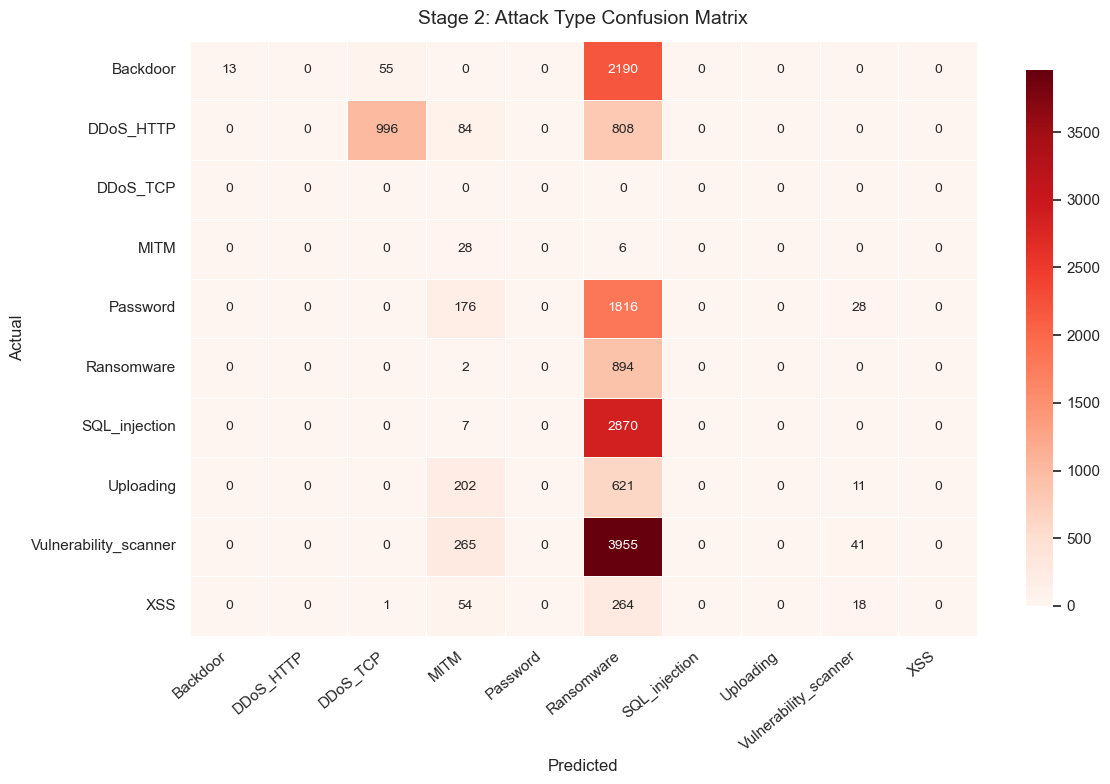

In [29]:
# Build confusion matrix using the full label space first
all_labels = np.arange(len(le_type.classes_))
cm = confusion_matrix(y_test_type_att, test_pred, labels=all_labels)

# Keep only classes that actually appear in y_true or y_pred
present_classes = np.unique(np.concatenate([y_test_type_att, test_pred]))
cm_present = cm[np.ix_(present_classes, present_classes)]
class_names_present = le_type.classes_[present_classes]

plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

ax = sns.heatmap(
    cm_present,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white",
    xticklabels=class_names_present,
    yticklabels=class_names_present,
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.9}
)

ax.set_title("Stage 2: Attack Type Confusion Matrix", fontsize=14, pad=12)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)

plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()